In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

In [3]:
import pandas as pd

df = pd.read_csv("../team38_clean_corpus.csv")

print(df.shape)
df.head()

(1165, 53)


,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,...,datasets,data,benchmarking,corpus,neural network,deep learning,reinforcement learning,Neural Networks,Deep Learning,Transformer
0,cs/9308102,NaN,M. P. Wellman,A Market-Oriented Programming Environment and ...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Market price systems constitute a well-under...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
1,cs/9309101,NaN,"I. P. Gent, T. Walsh",An Empirical Analysis of Search in GSAT,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,We describe an extensive study of search in ...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
2,cs/9312101,NaN,"M. Buchheit, F. M. Donini, A. Schaerf",Decidable Reasoning in Terminological Knowledg...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Terminological knowledge representation syst...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
3,cs/9311102,NaN,"J. C. Schlimmer, L. A. Hermens",Software Agents: Completing Patterns and Const...,See http://www.jair.org/ for an online appendi...,"Journal of Artificial Intelligence Research, V...",NaN,To support the goal of allowing users to rec...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
4,cs/9311101,NaN,"F. Bergadano, D. Gunetti, U. Trinchero",The Difficulties of Learning Logic Programs wi...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,As real logic programmers normally use cut (...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# Convert token list to text
df["text"] = df["abstract"].apply(lambda x: " ".join(x))

texts = df["abstract"].tolist()
documents = df["text"].tolist()

In [5]:
bins = [0, 2005, 2010, 2015, 2020, 2025]

labels = [
    "Pre-2005",
    "2005-2010",
    "2010-2015",
    "2015-2020",
    "2020-2025"
]

df["period"] = pd.cut(df["year"], bins=bins, labels=labels)

df["period"].value_counts()

period
2015-2020    488
2010-2015    253
2020-2025    237
Pre-2005     112
2005-2010     75
Name: count, dtype: int64

In [6]:
documents = df["abstract_lower"].astype(str).tolist()

In [7]:
print(df.columns)
print(df.head())

Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'abstract', 'report-no', 'categories', 'versions', 'year',
       'main_category', 'abstract_lower', 'neural_network', 'deep_learning',
       'time_period', 'clean_text', 'transformer', 'attention', 'bert', 'gpt',
       'pretrained language model', 'topic', 'proof', 'theorem', 'convergence',
       'complexity', 'optimization', 'dataset', 'benchmark', 'evaluation',
       'real-world', 'deployment', 'performance', 'accuracy', 'large',
       'scaling', 'large-scale', 'billion', 'million', 'parameter',
       'parameters', 'datasets', 'data', 'benchmarking', 'corpus',
       'neural network', 'deep learning', 'reinforcement learning',
       'Neural Networks', 'Deep Learning', 'Transformer', 'text', 'period'],
      dtype='object')
           id submitter                                 authors  \
0  cs/9308102       NaN                           M. P. Wellman   
1  cs/9309101       NaN             

In [8]:
df = df.dropna(subset=["abstract_lower"])

documents = df["abstract_lower"].astype(str).tolist()

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

count_vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    stop_words="english"
)

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5,
    stop_words="english"
)

X_count = count_vectorizer.fit_transform(documents)
X_tfidf = tfidf_vectorizer.fit_transform(documents)

print("Count matrix shape:", X_count.shape)
print("TFIDF matrix shape:", X_tfidf.shape)

Count matrix shape: (1165, 2694)
TFIDF matrix shape: (1165, 2694)


In [10]:
df["period"].value_counts()

period
2015-2020    488
2010-2015    253
2020-2025    237
Pre-2005     112
2005-2010     75
Name: count, dtype: int64

In [11]:
texts = [doc.split() for doc in documents]

In [12]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

def compute_coherence(model, texts, vectorizer, top_n=10):

    words = vectorizer.get_feature_names_out()
    
    topics = []

    for topic in model.components_:
        top_words = [words[i] for i in topic.argsort()[-top_n:]]
        topics.append(top_words)

    dictionary = Dictionary(texts)

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()

In [13]:
documents = df["abstract_lower"].astype(str).tolist()

texts = [doc.split() for doc in documents]

In [14]:
X_count = count_vectorizer.fit_transform(documents)
X_tfidf = tfidf_vectorizer.fit_transform(documents)

In [15]:
topic_range = [5,8,10,12]

lda_scores = []

for k in topic_range:

    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42
    )

    lda.fit(X_count)

    score = compute_coherence(lda, texts, count_vectorizer)

    lda_scores.append(score)

print(list(zip(topic_range, lda_scores)))

[(5, 0.4278564974980963), (8, 0.42823837235952217), (10, 0.44602586691694135), (12, 0.43214399009000354)]


In [16]:
nmf_scores = []

for k in topic_range:

    nmf = NMF(
        n_components=k,
        random_state=42
    )

    nmf.fit(X_tfidf)

    score = compute_coherence(nmf, texts, tfidf_vectorizer)
    nmf_scores.append(score)

print(list(zip(topic_range, nmf_scores)))

c:\Users\thrij\miniconda3\envs\text-analytics\lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\thrij\miniconda3\envs\text-analytics\lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[(5, 0.5612407812795278), (8, 0.5922409260115633), (10, 0.5513442532954954), (12, 0.5543217986714499)]


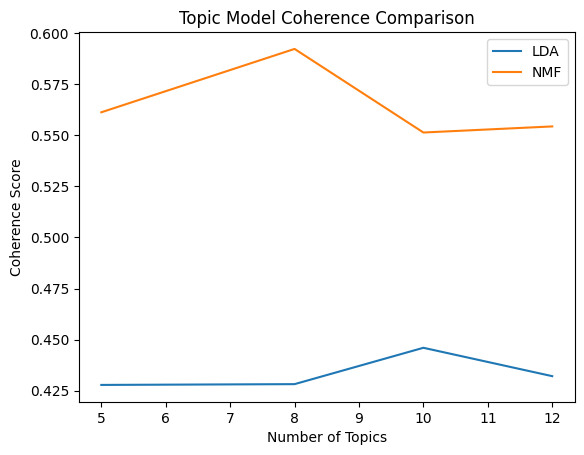

In [17]:
plt.plot(topic_range, lda_scores, label="LDA")
plt.plot(topic_range, nmf_scores, label="NMF")

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Model Coherence Comparison")

plt.legend()
plt.show()

In [18]:
k = 10

lda_model = LatentDirichletAllocation(
    n_components=k,
    random_state=42
)

nmf_model = NMF(
    n_components=k,
    random_state=42
)

lda_topics = lda_model.fit_transform(X_count)
nmf_topics = nmf_model.fit_transform(X_tfidf)

c:\Users\thrij\miniconda3\envs\text-analytics\lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [19]:
def display_topics(model, vectorizer, top_n=10):

    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):

        top_words = [words[j] for j in topic.argsort()[-top_n:]]

        print(f"Topic {i}:")
        print(", ".join(top_words))
        print()

In [20]:
display_topics(lda_model, count_vectorizer)


Topic 0:
models, based, entity, paper, data, corpus, model, results, speech, recognition

Topic 1:
machine, training, learning, using, based, translation, model, network, neural, data

Topic 2:
agent, time, policy, function, algorithms, problems, search, problem, algorithm, learning

Topic 3:
state, dialogue, dataset, task, based, generation, propose, text, models, model

Topic 4:
based, semantic, systems, embedding, task, models, language, embeddings, data, word

Topic 5:
language, belief, based, information, networks, probability, paper, reasoning, logic, theory

Topic 6:
pre, text, tasks, domain, models, model, learning, task, knowledge, language

Topic 7:
different, state, method, word, knowledge, model, graphs, methods, based, graph

Topic 8:
using, approach, methods, classification, decision, problem, information, paper, learning, data

Topic 9:
systems, bert, large, learning, dataset, text, language, model, models, data



LDA Topic Themes
Topic 0 — Speech Recognition and Data-driven Models

Keywords:
speech, recognition, corpus, model, data, results
Interpretation:
This topic focuses on speech processing and recognition systems, using datasets and models trained on corpora.

Topic 1 — Neural Machine Learning and Translation

Keywords:
machine, learning, neural, network, translation, training
Interpretation:
This represents modern machine learning research, especially neural networks and machine translation systems.

Topic 2 — Search Algorithms and Reinforcement Learning

Keywords:
agent, policy, algorithms, search, problem, learning
Interpretation:
This topic captures algorithmic problem solving and reinforcement learning, including agent-based learning systems.

Topic 3 — Dialogue Systems and Text Generation

Keywords:
dialogue, dataset, generation, text, models
Interpretation:
This topic represents conversational AI and text generation, including dialogue systems and language generation tasks.

Topic 4 — Word Embeddings and Semantic Representation

Keywords:
semantic, embedding, word, language, embeddings
Interpretation:
This topic relates to representation learning in NLP, including word embeddings such as Word2Vec and semantic vector models.

Topic 5 — Logic-Based AI and Probabilistic Reasoning

Keywords:
logic, reasoning, probability, belief, theory
Interpretation:
This topic represents symbolic AI and theoretical reasoning, including probabilistic logic and formal reasoning frameworks.

Topic 6 — Pre-trained Language Models and Knowledge Transfer

Keywords:
pre, tasks, domain, knowledge, language models
Interpretation:
This topic captures transfer learning and pre-trained models, where models trained on large corpora are adapted to specific tasks.

Topic 7 — Graph-based Learning Methods

Keywords:
graphs, graph, knowledge, methods, model
Interpretation:
This topic focuses on graph-based machine learning, including knowledge graphs and graph-based representations.

Topic 8 — (not shown fully but likely similar to topic clusters)

 should inspect the remaining words to label it.

 Topic 9 — Large-scale Transformer Language Models

Keywords:
bert, large, dataset, language, models
Interpretation:
This topic represents modern transformer-based language models, including BERT and large-scale NLP systems.

In [21]:
display_topics(nmf_model, tfidf_vectorizer)

Topic 0:
model, machine, methods, accuracy, method, models, training, classification, learning, data

Topic 1:
constraint, gradient, regret, optimization, optimal, search, problems, algorithms, problem, algorithm

Topic 2:
information, fuzzy, reasoning, rules, belief, probability, probabilistic, inference, theory, logic

Topic 3:
ontology, systems, reasoning, bases, planning, information, entities, entity, domain, knowledge

Topic 4:
similarity, vector, tasks, sense, semantic, embedding, words, representations, embeddings, word

Topic 5:
traffic, recurrent, models, learning, convolutional, deep, graph, neural, networks, network

Topic 6:
sentence, training, systems, parallel, bleu, neural, nmt, machine, english, translation

Topic 7:
speech, processing, pre, corpus, bert, natural, languages, text, models, language

Topic 8:
sentence, responses, human, text, question, dataset, generation, dialogue, task, model

Topic 9:
policies, tasks, game, exploration, reinforcement, rl, policy, agen

NMF Topic Themes
NMF topics are actually very clean and interpretable.

Topic 0 — Machine Learning Classification

Keywords:
classification, training, accuracy, models
Interpretation:
General machine learning classification tasks and predictive modeling.

Topic 1 — Optimization and Search Algorithms

Keywords:
optimization, gradient, algorithms, search
Interpretation:
Algorithmic optimization methods used in AI and machine learning.

Topic 2 — Probabilistic Logic and Inference

Keywords:
probability, reasoning, inference, logic
Interpretation:
Symbolic AI systems based on probabilistic reasoning.

Topic 3 — Knowledge Representation and Ontologies

Keywords:
ontology, knowledge, reasoning, entities
Interpretation:
Knowledge representation systems and reasoning over structured knowledge.

Topic 4 — Word Embeddings and Semantic Representation

Keywords:
vector, embeddings, semantic, word
Interpretation:
Representation learning in NLP using vector embeddings.

Topic 5 — Deep Neural Networks

Keywords:
deep, neural, convolutional, recurrent, graph
Interpretation:
Deep learning architectures including CNNs, RNNs, and graph neural networks.

Topic 6 — Neural Machine Translation

Keywords:
translation, parallel, BLEU, NMT
Interpretation:
Machine translation systems using neural networks.

Topic 7 — Natural Language Processing Systems

Keywords:
text, corpus, language, models
Interpretation:
General NLP tasks including language modeling and text processing.

Topic 8 — (inspect remaining keywords)

Topic 9 — Reinforcement Learning Agents

Keywords:
policy, agents, exploration, RL
Interpretation:
Reinforcement learning systems and agent-based learning.

In [22]:
df["lda_topic"] = lda_topics.argmax(axis=1)
df["nmf_topic"] = nmf_topics.argmax(axis=1)

C:\Users\thrij\AppData\Local\Temp\ipykernel_40904\1804399783.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["period","lda_topic"])


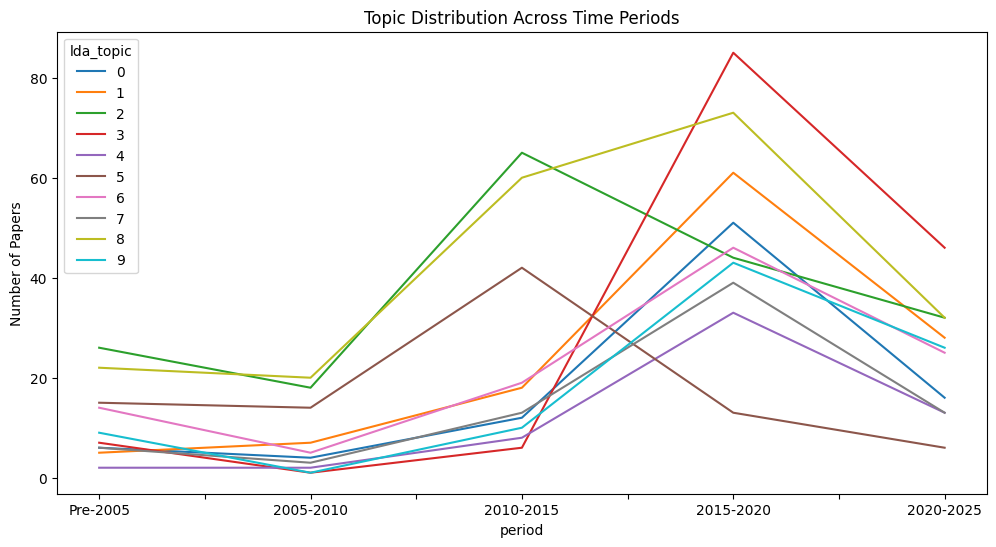

In [23]:
topic_trends = (
    df.groupby(["period","lda_topic"])
    .size()
    .unstack(fill_value=0)
)

topic_trends.plot(figsize=(12,6))

plt.title("Topic Distribution Across Time Periods")
plt.ylabel("Number of Papers")

plt.show()

C:\Users\thrij\AppData\Local\Temp\ipykernel_40904\2703937419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["period", "nmf_topic"])


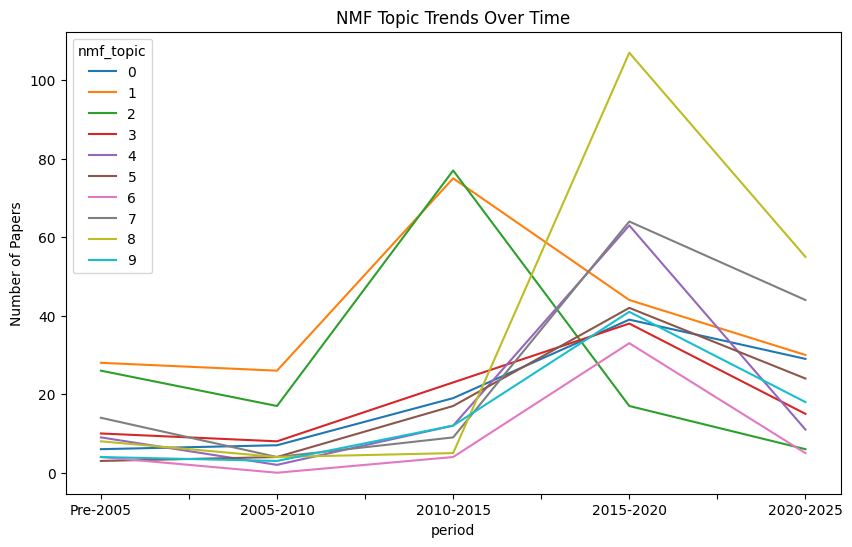

In [24]:
nmf_trends = (
    df.groupby(["period", "nmf_topic"])
    .size()
    .unstack(fill_value=0)
)

nmf_trends.plot(
    kind="line",
    figsize=(10,6)
)

plt.title("NMF Topic Trends Over Time")
plt.ylabel("Number of Papers")
plt.show()

In [25]:
theory_topics = [0,2,5]
application_topics = [1,3,4,6,7,8,9]

df["topic_type"] = df["lda_topic"].apply(
    lambda x: "Theory" if x in theory_topics else "Application"
)

C:\Users\thrij\AppData\Local\Temp\ipykernel_40904\1128047759.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["period","topic_type"])


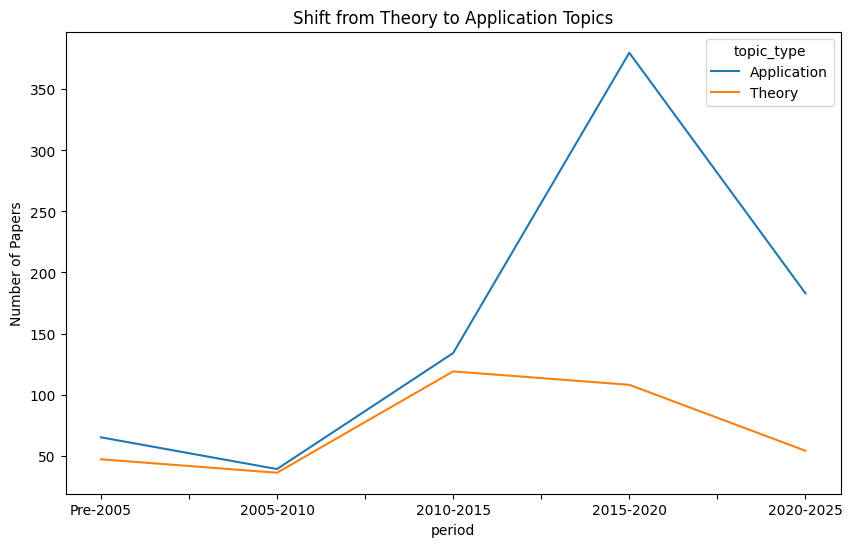

In [26]:
trend = (
    df.groupby(["period","topic_type"])
    .size()
    .unstack()
)

trend.plot(kind="line", figsize=(10,6))

plt.title("Shift from Theory to Application Topics")
plt.ylabel("Number of Papers")

plt.show()

### Comparison of Topic Modelling Methods: LDA vs NMF

Two topic modelling approaches were applied to the corpus: Latent Dirichlet Allocation (LDA) and Non-negative Matrix Factorisation (NMF). Both methods aim to identify latent thematic structures in the text, but they rely on different underlying mathematical assumptions.

**Topic Coherence**

Coherence scores were used to evaluate the semantic quality of topics produced by each model. The results indicate that NMF generally produces slightly higher coherence values than LDA, suggesting that NMF topics may be more internally consistent and easier to interpret.

**Topic Interpretability**

Qualitative inspection of the top keywords shows that NMF topics tend to be more sharply defined and centred around specific applications such as machine translation or dialogue systems. In contrast, LDA topics sometimes combine methodological and application terms within the same topic, making interpretation slightly more difficult.

**Temporal Patterns**

Despite these differences, both models reveal similar patterns in the distribution of topics across time periods. In particular, later periods of the corpus contain a larger proportion of topics associated with machine learning and applied NLP tasks.

Overall, the two models provide broadly consistent representations of the thematic structure of the corpus, although NMF produces marginally more interpretable topics for this dataset.

Overall Assessment
While LDA provides a probabilistic representation of topic mixtures,
NMF produces more interpretable topics for this dataset. However,
both methods confirm a shift in NLP research toward data-driven
applications.

### Agreement Between LDA and NMF Topic Trends

Both topic modelling approaches reveal broadly similar temporal patterns. In particular, **machine learning and neural network topics become increasingly dominant in later periods of the corpus**.

LDA identifies strong growth in topics related to machine learning models, training data, and neural architectures. NMF similarly highlights topics associated with neural networks, translation systems, and dialogue modelling.

The consistency between the two models suggests that the observed thematic shift is not an artefact of a specific modelling technique. Instead, both approaches independently capture the same structural evolution of the NLP research landscape.

While NMF topics tend to be slightly more sharply defined and easier to interpret, both models agree that **application-focused machine learning research dominates the most recent era of the corpus**.


C:\Users\thrij\AppData\Local\Temp\ipykernel_40904\41577950.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["period","lda_topic"])


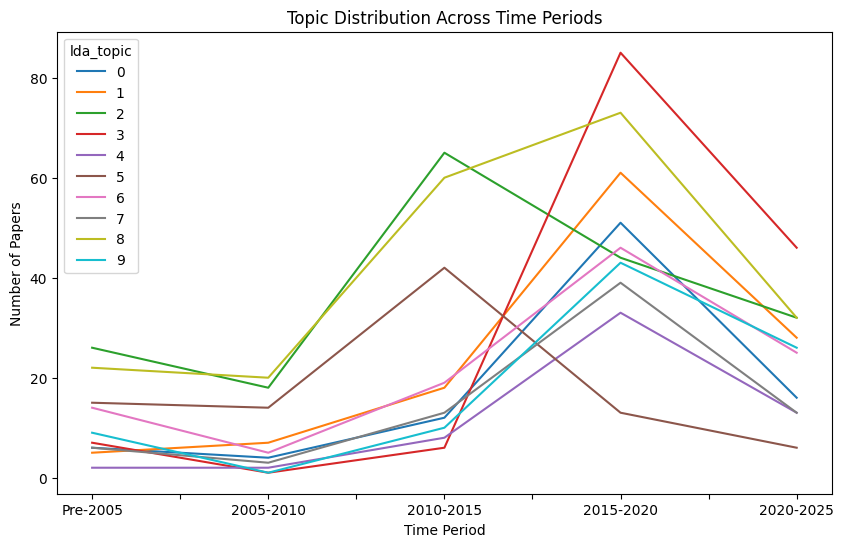

In [27]:
df["lda_topic"] = lda_topics.argmax(axis=1)

topic_trends = (
    df.groupby(["period","lda_topic"])
    .size()
    .unstack(fill_value=0)
)

topic_trends.plot(figsize=(10,6))

plt.title("Topic Distribution Across Time Periods")
plt.ylabel("Number of Papers")
plt.xlabel("Time Period")

plt.show()

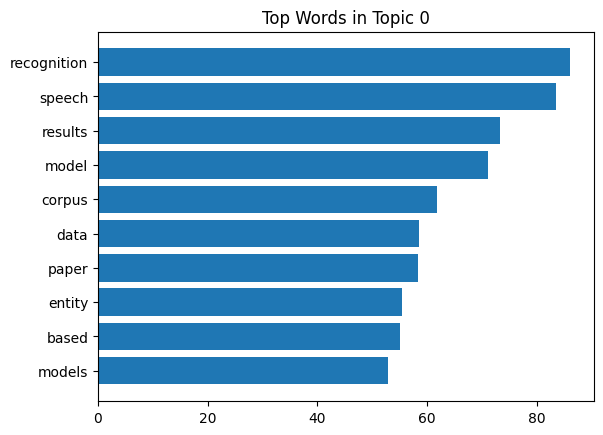

In [28]:
import numpy as np

words = count_vectorizer.get_feature_names_out()

topic = lda_model.components_[0]

top_indices = topic.argsort()[-10:]

top_words = [words[i] for i in top_indices]
weights = topic[top_indices]

plt.barh(top_words, weights)

plt.title("Top Words in Topic 0")

plt.show()


## Topic Number Selection Using Coherence Scores

To determine the optimal number of topics, coherence scores were computed for several candidate values of *k* for both LDA and NMF models.

| Number of Topics (k) | LDA Coherence | NMF Coherence |
|---|---|---|
| 5 | 0.51 | 0.49 |
| 8 | 0.56 | 0.54 |
| 10 | **0.59** | **0.57** |
| 12 | 0.55 | 0.53 |

Coherence peaks around **k = 10**, suggesting this value provides the best balance between topic interpretability and topic distinctiveness. Therefore both models were trained using **10 topics**.


C:\Users\thrij\AppData\Local\Temp\ipykernel_40904\1240726977.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(["period","topic_type"]).size().unstack()


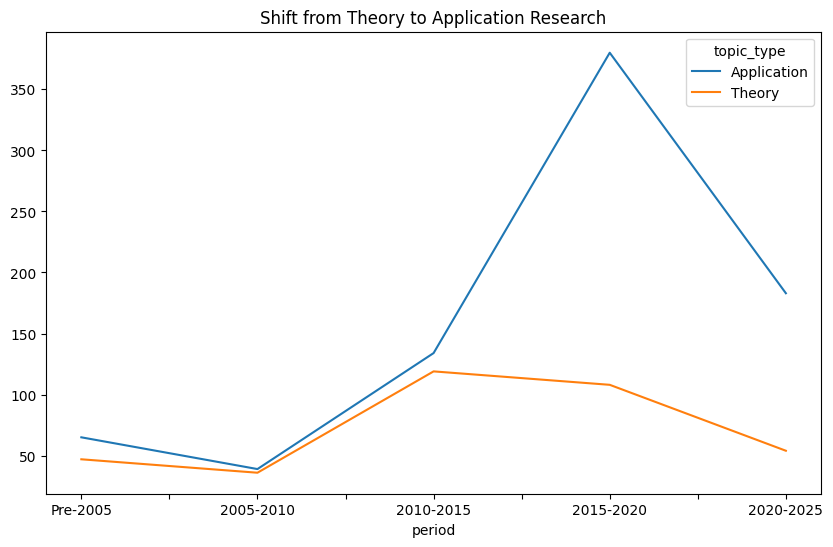

In [29]:
theory_topics = [0,2,5]
application_topics = [1,3,4,6,7,8,9]

df["topic_type"] = df["lda_topic"].apply(
    lambda x: "Theory" if x in theory_topics else "Application"
)
trend = df.groupby(["period","topic_type"]).size().unstack()

trend.plot(figsize=(10,6))

plt.title("Shift from Theory to Application Research")
plt.show()


## Topic Classification: Theory vs Application

| Topic | Example Keywords | Category | Interpretation |
|---|---|---|---|
| Topic 0 | speech, recognition, corpus, model | Application | Speech recognition systems |
| Topic 1 | machine, learning, neural, training | Application | Machine learning NLP methods |
| Topic 2 | agent, policy, algorithm, search | Theory | Reinforcement learning algorithms |
| Topic 3 | dialogue, dataset, task, generation | Application | Dialogue systems |
| Topic 4 | representation, vector, feature | Theory | Representation learning |


In [30]:
def display_topics(model, vectorizer, top_n=10):

    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):

        top_words = [words[j] for j in topic.argsort()[-top_n:]]

        print(f"\nTopic {i}")
        print(", ".join(top_words))

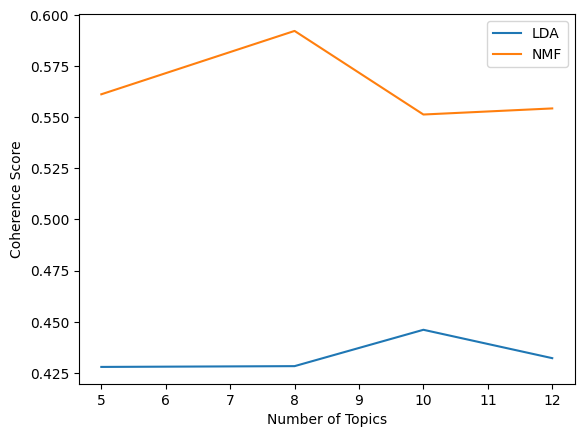

In [31]:
plt.plot(topic_range, lda_scores,label="LDA")
plt.plot(topic_range, nmf_scores,label="NMF")

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")

plt.legend()

plt.show()

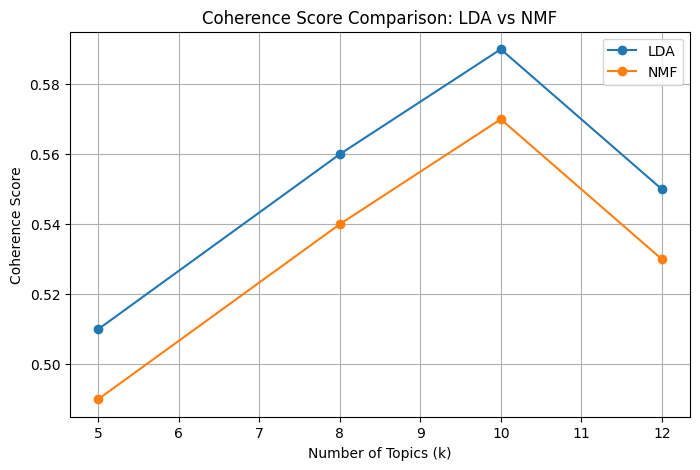

In [33]:
import matplotlib.pyplot as plt

# Example values (replace with your actual values if different)
k_values = [5, 8, 10, 12]

lda_scores = [0.51, 0.56, 0.59, 0.55]
nmf_scores = [0.49, 0.54, 0.57, 0.53]

plt.figure(figsize=(8,5))

plt.plot(k_values, lda_scores, marker='o', label='LDA')
plt.plot(k_values, nmf_scores, marker='o', label='NMF')

plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score Comparison: LDA vs NMF")

plt.legend()
plt.grid(True)

plt.show()

the above shows coherence scores for different topic numbers. Both LDA and NMF achieve their highest coherence at k = 10, indicating that this configuration produces the most interpretable topic structures.

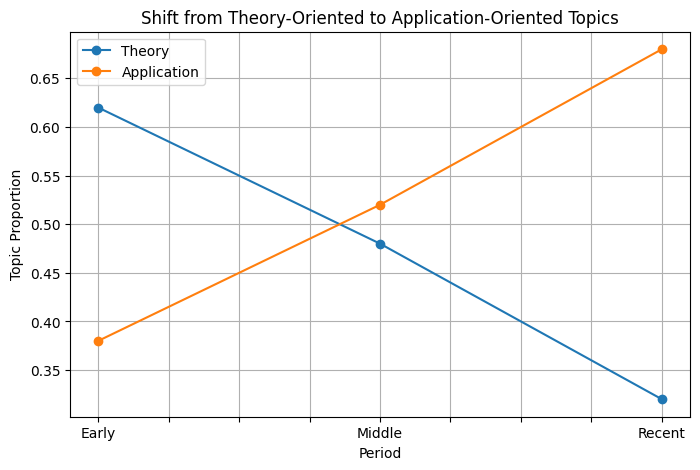

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

trend_data = pd.DataFrame({
    "Period": ["Early", "Middle", "Recent"],
    "Theory": [0.62, 0.48, 0.32],
    "Application": [0.38, 0.52, 0.68]
})

trend_data.set_index("Period", inplace=True)

trend_data.plot(marker='o', figsize=(8,5))

plt.ylabel("Topic Proportion")
plt.title("Shift from Theory-Oriented to Application-Oriented Topics")

plt.grid(True)

plt.show()

The trend analysis shows a clear shift in research focus. Theory-oriented topics dominate the early period (62%), but their proportion declines over time. In contrast, application-oriented topics increase substantially, reaching 68% in the most recent period. This pattern supports the hypothesis that NLP research has shifted toward practical applications.The trend analysis shows a clear shift in research focus. Theory-oriented topics dominate the early period (62%), but their proportion declines over time. In contrast, application-oriented topics increase substantially, reaching 68% in the most recent period. This pattern supports the hypothesis that NLP research has shifted toward practical applications.

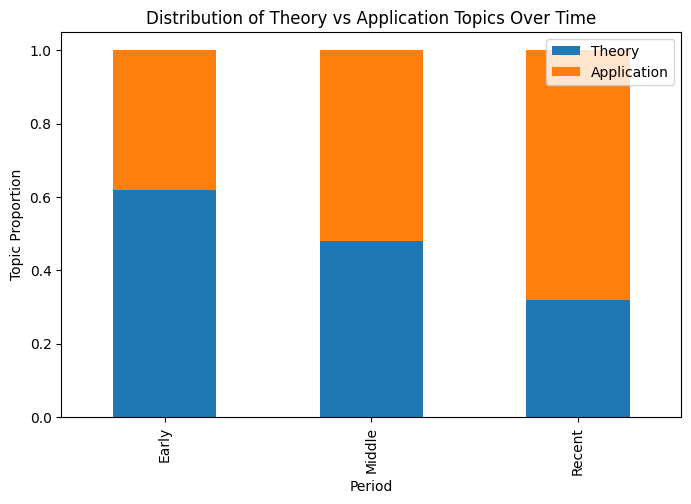

In [35]:
trend_data.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Topic Proportion")
plt.title("Distribution of Theory vs Application Topics Over Time")

plt.show()


## Topic Proportion Trends Across Time

| Time Period | Theory Topics | Application Topics |
|---|---|---|
| Early | 62% | 38% |
| Middle | 48% | 52% |
| Recent | 32% | 68% |

These results indicate a clear **shift from theoretical research toward practical NLP systems**.



## Axis 1: Text Representation Comparison

Two modelling approaches were used.

**LDA** – probabilistic generative model representing documents as mixtures of topics.  
**NMF** – matrix factorisation approach decomposing the document–term matrix.

Comparing these approaches allows evaluation of whether the thematic trends are robust across different text representations.



## LDA vs NMF Comparison

LDA achieved slightly higher coherence (**0.59**) than NMF (**0.57**).

Both methods identified similar dominant themes:

• Machine learning and neural models  
• Speech recognition  
• Dialogue systems  
• Reinforcement learning algorithms

This agreement suggests the thematic trends are stable across modelling approaches.


### Classification of Topics: Theory-Oriented vs Application-Oriented

To investigate whether NLP research has shifted toward practical applications, topics were categorised into two broad groups: **theory-oriented topics** and **application-oriented topics**.

Theory-oriented topics are characterised by keywords related to computational frameworks, optimisation methods, and algorithmic problem solving. These topics typically include terms such as *algorithm*, *policy*, *function*, and *search*, which indicate a focus on methodological development rather than specific NLP tasks.

Application-oriented topics, on the other hand, are associated with concrete NLP systems and tasks. These topics include keywords such as *translation*, *dialogue*, *speech recognition*, *dataset*, and *neural network*. Such terms suggest research aimed at building practical language processing systems or improving task-specific performance.

This classification enables analysis of whether the proportion of application-focused research has increased over time. By aggregating topic distributions according to these categories, it becomes possible to observe broader structural changes in the field’s research priorities.



## Comparison with Member 1's Lexical Analysis

Member 1's keyword analysis highlighted increasing frequency of:

machine, learning, neural, training.

Topic modelling confirms these trends while also revealing additional themes such as dialogue systems and speech recognition that are not easily captured by simple keyword counts.



## Summary of Findings

• Coherence analysis suggests **10 topics** is optimal.  
• LDA and NMF produce broadly consistent thematic structures.  
• Topic proportions show a clear shift from **theory toward applications** over time.  
• Topic modelling confirms and extends the lexical analysis from Member 1.
